In [500]:
from scipy.stats import invgamma

import numpy as np
import torch
from abc import ABC, abstractmethod
import numpy as np
import torch
from torch import autograd, nn
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Callable, Literal, overload
from tqdm.notebook import tqdm
# from scipy.stats import gaussian_kde
import pandas as pd

import random

In [501]:
SEED_DEFAULT = 34
sns.set_theme()
torch.manual_seed(SEED_DEFAULT)
rng = np.random.default_rng(SEED_DEFAULT)
 # Python
random.seed(SEED_DEFAULT)

# NumPy
np.random.seed(SEED_DEFAULT)

# PyTorch CPU
torch.manual_seed(SEED_DEFAULT)

# PyTorch CUDA
torch.cuda.manual_seed(SEED_DEFAULT)
torch.cuda.manual_seed_all(SEED_DEFAULT)

# Forçar determinismo
torch.use_deterministic_algorithms(True)

# Evitar fontes não determinísticas no CUDA
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.set_grad_enabled(True)

torch.autograd.grad_mode.set_grad_enabled(mode=True)

# Funções, classes e implementações auxiliares

In [524]:
# @title Sampler
class Sampler:
    def __init__(self, f_log_prob: Callable |None = None, device = None, dtype = torch.float64):
        self.__f_log_prob = f_log_prob
        self.amostras = None
        self.__device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.__dtype = dtype

    @property
    def f_log_prob(self):
        return self.__f_log_prob

    @f_log_prob.setter
    def f_log_prob(self, f_log_prob):
        self.__f_log_prob = f_log_prob

    def __mh_updater(self, estado_atual: torch.Tensor, logp_atual: float, use_log_pdf: bool, f_next_state: Callable|None = None, cov_random_walk=None):
        was_scalar = False
        if estado_atual.ndim == 0:
            estado_atual = estado_atual.unsqueeze(-1)
            was_scalar = True
        if not f_next_state:
            dim = estado_atual.shape[-1]
            cov = torch.eye(dim, device=estado_atual.device, dtype=estado_atual.dtype)
            if cov_random_walk:
                 cov *= cov_random_walk
            else:
                cov *= 0.1
            f_next_state = lambda x: torch.distributions.MultivariateNormal(x, covariance_matrix=cov).sample()
        estado_proposto = f_next_state(estado_atual)

        # verossimilhanca
        logp_proposto = self.__f_log_prob(estado_proposto)
        # threshold atual
        threshold = torch.rand((), device=self.__device, dtype=self.__dtype)
        if use_log_pdf:
            threshold = threshold.log()

            # # --- > if (log(verossimilhanca_propost / verossimilhanca_atual)) > log(threshcold)
            # # --- > if (log(verossimilhanca_propost) - log(verossimilhanca_atual)) > log(threshcold
            # print("proposto: ", logp_proposto)
            # print("atual: ", logp_atual)
            # print(f"threshold {threshold} < {logp_proposto - logp_atual} proposto - atual ==>  ", threshold < logp_proposto - logp_atual)
            # print(threshold)
            # print("-"*25)
            # print(logp_proposto)
            if threshold < logp_proposto - logp_atual:
                return estado_proposto, estado_proposto, logp_proposto, True

            return estado_atual, estado_proposto, logp_atual, False

        aceitacao_raio = logp_proposto / logp_atual
        if threshold < min(aceitacao_raio, 1):
            return estado_proposto, estado_proposto, logp_proposto, True

        return estado_atual, estado_proposto, logp_atual, False

    def __hmc_updater(self, estado_atual: torch.Tensor, logp_atual: float, step_size, n_steps: int, f_grad_log_prob: Callable):
        r0 = torch.randn_like(estado_atual, device= self.__device, dtype=self.__dtype)

        valor_inicial = logp_atual - 0.5 * torch.sum(r0**2)

        #leapfrog_integration
        # https://www.tcbegley.com/blog/posts/mcmc-part-2
        theta = estado_atual.clone()
        r = r0.clone()

        r = r + 0.5 * step_size * f_grad_log_prob(theta)
        for _ in range(n_steps):
            theta = theta + step_size * r

            grad = f_grad_log_prob(theta)
            if _ != n_steps - 1:
                r = r + step_size * grad

        r = r + 0.5 * step_size * grad
        r = -r

        logp_proposto = self.__f_log_prob(theta)

        valor_final = logp_proposto - 0.5 * torch.sum(r ** 2)

        log_accept_ratio = valor_final - valor_inicial
        threshold = torch.rand((), device=self.__device, dtype=self.__dtype).log()
        if threshold < log_accept_ratio:
            return theta, theta, logp_proposto, True

        return estado_atual, theta, logp_atual, False

    @overload
    def get_samples(self, method: Literal["mh"], estado_inicial: torch.Tensor, use_log_pdf: bool, n_amostras: int = 1000, burnin: float = 0.2, f_next_state: Callable|None = None) -> torch.Tensor: ...

    @overload
    def get_samples(self, method: Literal["hmc"], estado_inicial: torch.Tensor, step_size, n_steps: int, f_grad_log_prob: Callable, n_amostras: int = 1000, burnin: float = 0.2) -> torch.Tensor: ...

    def get_samples(self, method: str, estado_inicial: torch.Tensor, n_amostras: int=1000, burnin: float=0.2, show_progress=True, **kwargs):
        if method.lower() == "mh":
            updater = self.__mh_updater
        elif method.lower() == "hmc":
            updater = self.__hmc_updater
        else:
            raise ValueError("method deve ser 'hmc' ou 'mh'")

        if self.__f_log_prob is None:
            raise ValueError("f_log_prob é um argumento necessário para a execução de qualquer método")

        estado_atual = torch.as_tensor(estado_inicial, device=self.__device, dtype=self.__dtype)
        logp_atual = self.__f_log_prob(estado_atual)

        burnin_amostras = int(burnin * n_amostras)
        amostras = []
        burned = []
        not_accepted = []

        pbar = tqdm(total=n_amostras, desc="Amostrando", disable=not show_progress)
        iter_count = 0

        while (len(amostras) < n_amostras) and (iter_count < 10_000):

            estado_atual, estado_proposto, logp_atual, foi_aceito = updater(
                estado_atual, logp_atual, **kwargs
            )

            # burn-in por iteração
            if iter_count < burnin_amostras:
                burned.append(estado_atual.clone())
            else:
                amostras.append(estado_atual.clone())
                pbar.update(1)

            if not foi_aceito:
                not_accepted.append(estado_proposto.clone())

            iter_count += 1


        pbar.close()
        retorno = []
        if amostras:
            self.amostras = torch.stack(amostras)
            retorno.append(self.amostras)
        else:
            retorno.append(None)

        if burned:
            self.burned = torch.stack(burned)
            retorno.append(self.burned)
        else:
            retorno.append(None)

        if not_accepted:
            self.not_accepted = torch.stack(not_accepted)
            retorno.append(self.not_accepted)
        else:
            retorno.append(None)

        return retorno

    def plot_cadeia(self,
                amostras=None,
                burned=None,
                not_used=None,
                save_path: str | None = None,
                show_img: bool = False,
                plot_not_used: bool = True,
                bins: int = 60,
                kde: bool = True,
                kde_points: int = 400):
        """
        Plota 3 eixos:
        (1) trace ao longo do tempo (burned / not_used / accepted)
        (2) hist + KDE das 3 séries (overlay)
        (3) hist + KDE só das aceitas
        """

        # -------- helpers --------
        def _to_1d(x, name):
            if x is None:
                return None
            x = torch.as_tensor(x).detach().flatten().cpu().double().numpy()
            if x.size == 0:
                raise ValueError(f"{name} está vazio.")
            return x

        def _gaussian_kde_1d(samples, grid):
            # KDE Gaussiano simples (Silverman)
            # Evita dependência de scipy
            x = np.asarray(samples, dtype=float)
            n = x.size
            if n < 2:
                return np.full_like(grid, np.nan, dtype=float)

            std = x.std(ddof=1)
            if std == 0:
                # distribuição degenerada
                return np.zeros_like(grid, dtype=float)

            h = 1.06 * std * (n ** (-1/5))  # Silverman
            h = max(h, 1e-12)

            z = (grid[:, None] - x[None, :]) / h
            dens = np.exp(-0.5 * z**2).mean(axis=1) / (h * np.sqrt(2*np.pi))
            return dens

        # -------- load series --------
        accepted = _to_1d(amostras if amostras is not None else self.amostras, "amostras (accepted)")
        if accepted is None:
            raise ValueError("O valor de amostras deve ser passado ou gerado através de um método de amostragem")

        if plot_not_used:
            burned_arr = _to_1d(burned if burned is not None else getattr(self, "burned", None), "burned")
            not_used_arr = _to_1d(not_used if not_used is not None else getattr(self, "not_accepted", None), "not_used/not_accepted")
        else:
            burned_arr = None
            not_used_arr = None

        # -------- colors --------
        c_burned = "purple"
        c_not_used = "tab:blue"
        c_accepted = "orange"

        # -------- prepare figure --------
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # =========================
        # (1) Trace plot (time)
        # =========================
        ax = axes[0]
        idx = 0

        if burned_arr is not None:
            x_b = np.arange(idx, idx + burned_arr.size)
            ax.plot(x_b, burned_arr, color=c_burned, linewidth=1.0, alpha=0.9, label="burned")
            idx += burned_arr.size

        if not_used_arr is not None:
            x_n = np.arange(idx, idx + not_used_arr.size)
            ax.plot(x_n, not_used_arr, color=c_not_used, linewidth=1.0, alpha=0.9, label="not_used")
            idx += not_used_arr.size

        x_a = np.arange(idx, idx + accepted.size)
        ax.plot(x_a, accepted, color=c_accepted, linewidth=1.0, alpha=0.9, label="accepted")

        ax.set_title("Trace (burned / not_used / accepted)")
        ax.set_xlabel("iter")
        ax.set_ylabel("value")
        ax.legend()

        # =========================
        # (2) Hist + KDE overlay (3 séries)
        # =========================
        ax = axes[1]

        # range comum pra ficar comparável
        all_series = [accepted]
        labels_colors = [("accepted", accepted, c_accepted)]
        if burned_arr is not None:
            all_series.append(burned_arr)
            labels_colors.append(("burned", burned_arr, c_burned))
        if not_used_arr is not None:
            all_series.append(not_used_arr)
            labels_colors.append(("not_used", not_used_arr, c_not_used))

        all_concat = np.concatenate(all_series)
        xmin, xmax = np.min(all_concat), np.max(all_concat)
        if xmin == xmax:
            xmin, xmax = xmin - 1.0, xmax + 1.0

        # hist overlay
        for name, arr, color in labels_colors:
            ax.hist(arr, bins=bins, range=(xmin, xmax), density=True, alpha=0.25, color=color, label=f"{name} hist")

        # kde overlay
        if kde:
            grid = np.linspace(xmin, xmax, kde_points)
            for name, arr, color in labels_colors:
                dens = _gaussian_kde_1d(arr, grid)
                ax.plot(grid, dens, color=color, linewidth=2.0, label=f"{name} kde")

        ax.set_title("Distribuição (hist + KDE) — burned / not_used / accepted")
        ax.set_xlabel("value")
        ax.set_ylabel("density")
        ax.legend()

        # =========================
        # (3) Só accepted (hist + KDE)
        # =========================
        ax = axes[2]
        ax.hist(accepted, bins=bins, density=True, alpha=0.30, color=c_accepted, label="accepted hist")

        if kde:
            xmin_a, xmax_a = accepted.min(), accepted.max()
            if xmin_a == xmax_a:
                xmin_a, xmax_a = xmin_a - 1.0, xmax_a + 1.0
            grid_a = np.linspace(xmin_a, xmax_a, kde_points)
            dens_a = _gaussian_kde_1d(accepted, grid_a)
            ax.plot(grid_a, dens_a, color=c_accepted, linewidth=2.0, label="accepted kde")

        ax.set_title("Distribuição — accepted apenas")
        ax.set_xlabel("value")
        ax.set_ylabel("density")
        ax.legend()

        plt.tight_layout()

        if isinstance(save_path, str):
            try:
                plt.savefig(save_path, dpi=200, bbox_inches="tight")
            except Exception as e:
                print("Erro ao tentar salvar imagem!")
                print(e)

        if show_img:
            plt.show()

        # return fig, axes

In [475]:
# @title distribuições base

class Distribution(ABC):
    @abstractmethod
    def pdf(self, x: torch.Tensor) -> torch.Tensor: ...

    @abstractmethod
    def log(self, x: torch.Tensor) -> torch.Tensor: ...

class InverseGamma(Distribution):
    def __init__(self, alpha, beta, device=None, dtype=torch.float64):
        # resolve device
        if device is None:
            device = "cuda" if torch.cuda.is_available() else "cpu"

        self.__device = device
        self.__dtype = dtype

        # parâmetros como tensores
        self.__alpha = torch.as_tensor(alpha, device=self.__device, dtype=self.__dtype)
        self.__beta  = torch.as_tensor(beta,  device=self.__device, dtype=self.__dtype)

    def pdf(self, x):
        return torch.exp(self.log(x))

    def log(self, x):
        if torch.any(x <= 0):
            return torch.full_like(x, -torch.inf)

        alpha = self.__alpha
        beta = self.__beta

        return (
            alpha * torch.log(beta)
            - torch.lgamma(alpha)
            - (alpha + 1) * torch.log(x)
            - beta / x
        )

    def grad_log(self, x):
        alpha = self.__alpha
        beta = self.__beta

        return (beta - (alpha + 1) * x) / (x ** 2)

    def sample(self, size=1):
        # Gamma(alpha, rate = beta)
        gamma_dist = torch.distributions.Gamma(self.__alpha, self.__beta)
        y = gamma_dist.sample((size,)).to(dtype=self.__dtype, device=self.__device)
        return 1/y

class Normal(Distribution):
    def __init__(self, media=0, sigma:float|int=1, device = None, dtype = torch.float64):
        self.__device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.__dtype = dtype
        self.__media = torch.tensor(media, dtype=self.__dtype, device=self.__device)
        self.__sigma = torch.tensor(sigma, dtype=self.__dtype, device=self.__device)
        self.__logZ = torch.log(2 * torch.pi * (self.__sigma ** 2))

    def pdf(self, x: torch.Tensor):
        return torch.exp(-(x - self.__media) ** 2 / (2 * self.__sigma ** 2)) / torch.sqrt(2 * torch.pi * (self.__sigma ** 2))

    def log(self, x: torch.Tensor):
        return -0.5 * (self.__logZ + (x - self.__media) ** 2 / (self.__sigma ** 2))

    def grad_log(self, x: torch.Tensor):
        return -(x - self.__media) / (self.__sigma ** 2)

    def sample(self, size=1):
        dist = torch.distributions.Normal(self.__media, self.__sigma)
        return dist.sample((size,)).to(dtype=self.__dtype, device=self.__device)

In [476]:
# @title conditional distributions

class NormalVarianciaDesconhecida:
    def __init__(self, mean: float|int) -> None:
        self.__mean = mean

    def pdf(self, x, variancia):
        return 1/(torch.sqrt(2 * torch.pi * variancia**2)) * torch.exp(-(x - self.__mean)**2 / (2 * variancia**2))

    def log(self, x, variancia):
        return -0.5 * (torch.log(2 * torch.pi * variancia**2) + (x - self.__mean)**2 / (variancia ** 2))

    def grad_log(self, x, variancia):
        return -(x - self.__mean) / (variancia ** 2)

    def grad_log_variancia(self, x, variancia):
        # x pode ser escalar ou vetor
        return (
            -0.5 / variancia
            + 0.5 * (x - self.__mean)**2 / (variancia**2)
        )

In [477]:
# @title parametric distribution

class ParametricDistribution:
    def __init__(self, target_priori, fake_priori, data_distribution, alpha_star, n, k, dtype=torch.float64) -> None:
        self.__target_priori = target_priori
        self.__fake_priori = fake_priori
        self.__data_distribution = data_distribution
        self.__dtype = dtype
        self.__alpha_star = alpha_star
        self.__rate = n / k

    def pdf_f(self, theta):
        data_evaluation_alpha = self.__data_distribution.pdf(self.__alpha_star, theta)
        prod_alphas = torch.prod(data_evaluation_alpha, dim=-1) ** self.__rate
        return self.__fake_priori.pdf(theta) * prod_alphas

    def log_f(self, theta):
        data_evaluation_alpha = self.__data_distribution.log(self.__alpha_star, theta)
        prod_alphas = torch.sum(data_evaluation_alpha, dim=-1) * self.__rate
        return self.__fake_priori.log(theta) + prod_alphas

    def pdf_s(self, theta):
        data_evaluation_alpha = self.__data_distribution.pdf(self.__alpha_star, theta)
        prod_alphas = torch.prod(data_evaluation_alpha, dim=-1) ** self.__rate
        return self.__target_priori.pdf(theta) * prod_alphas

    def log_s(self, theta):
        data_evaluation_alpha = self.__data_distribution.log(self.__alpha_star, theta)
        prod_alphas = torch.sum(data_evaluation_alpha, dim=-1) * self.__rate
        return self.__target_priori.log(theta) + prod_alphas

    def grad_log_s(self, theta):
        data_evaluation_alpha = self.__data_distribution.grad_log_variancia(self.__alpha_star, theta)
        prod_alphas = torch.sum(data_evaluation_alpha, dim=-1) * self.__rate
        return self.__target_priori.grad_log(theta) + prod_alphas

    def get_weight(self, thetas, pf_data):
        pf = self.pdf_f(thetas)
        pf_data_eval = pf_data(thetas)
        weights = pf_data_eval / pf
        weights = weights / torch.sum(weights)

        return weights

In [478]:
# @title funções base bandwidth
def bandwidth_scott_logtheta(thetas: torch.Tensor, eps: float = 1e-12):
    x = torch.as_tensor(thetas).detach().flatten()
    x = torch.clamp(x, min=eps)
    z = torch.log(x)
    Tf = z.numel()
    d = 1
    std = torch.std(z, unbiased=True)
    return std * (Tf ** (-1.0 / (d + 4)))  # Tf^{-1/5}

def bandwidth_silverman_logtheta(thetas: torch.Tensor, eps: float = 1e-12):
    x = torch.as_tensor(thetas).detach().flatten()
    x = torch.clamp(x, min=eps)
    z = torch.log(x)
    Tf = z.numel()

    q75 = torch.quantile(z, 0.75)
    q25 = torch.quantile(z, 0.25)
    iqr = q75 - q25
    std = torch.std(z, unbiased=True)
    s = torch.minimum(std, iqr / 1.34)
    return 0.9 * s * (Tf ** (-1.0 / 5.0))


In [504]:
# @title Loss SM e alpha optimization

def score_matching_loss_m2(theta_samples, n: int, a=2.0, b=0.5, log_m2=None):
    theta = torch.clamp(theta_samples, min=1e-12)          # (Tf,)
    theta = theta.view(1, -1)                              # (1, Tf)

    A = a + 1.0 + n/2.0                                    # escalar
    m2 = torch.exp(log_m2).view(-1, 1)                     # (k, 1)
    B = b + 0.5 * n * m2                                   # (k, 1)

    s  = -A/theta + B/(theta**2)                           # (k, Tf)
    d2 =  A/(theta**2) - 2.0*B/(theta**3)                  # (k, Tf)

    loss_per_k = 0.5*(s**2).mean(dim=1) + d2.mean(dim=1)   # (k,)
    return loss_per_k.mean()                               # escalar (agrega k)


def fit_m2_with_adam(theta_samples, n, size, a0, b0, steps=300, lr=0.05,
                     device=None, dtype=torch.float64, verbose=True, log_every=10):

    theta = torch.as_tensor(theta_samples, device=device, dtype=dtype).clone().detach()

    log_m2 = torch.nn.Parameter(0.05 * torch.randn(size, device=theta.device, dtype=theta.dtype))
    opt = torch.optim.Adam([log_m2], lr=lr)

    pbar = tqdm(range(steps), desc="Treinando m2 (Adam)", disable=not verbose)

    for it in pbar:
        opt.zero_grad(set_to_none=True)
        loss = score_matching_loss_m2(theta, n=n, a=a0, b=b0, log_m2=log_m2)
        loss.backward()
        opt.step()

        if verbose and (it % log_every == 0 or it == steps - 1):
            with torch.no_grad():
                m2_mean = torch.exp(log_m2).mean().item()
                m2_min  = torch.exp(log_m2).min().item()
                m2_max  = torch.exp(log_m2).max().item()

            # atualiza na própria barra (sem quebrar linha)
            pbar.set_postfix(
                loss=f"{loss.item():.4g}",
                lr=f"{opt.param_groups[0]['lr']:.2g}"
            )

    return torch.exp(log_m2).detach()


In [480]:
# @title Semi Parametric distribution
class SemiParametricDistribution:
    def __init__(self, parametric_density: ParametricDistribution, priori_target, priori_fake, thetas, bandwidth):
        if thetas.ndim == 1:
            thetas = thetas.reshape(-1, 1)

        self.__num_fake_samples, self.__theta_dimension = thetas.shape
        self.__thetas = thetas
        self.__bandwidth = bandwidth
        self.__parametric_density = parametric_density

        self.__priori_target = priori_target
        self.__priori_fake = priori_fake

    def kernel_function(self, theta_1, theta_2):
        return torch.exp(-0.5*torch.norm(theta_1 - theta_2, dim = -1)**2 / (self.__bandwidth**2))

    def log_kernel(self, theta):
        # força theta para (1, d)
        if theta.ndim == 0:
            theta = theta.view(1, 1)
        elif theta.ndim == 1:
            theta = theta.view(1, -1)

        diff = theta - self.__thetas            # (N,d)
        quad = torch.sum(diff**2, dim=-1)       # (N,)
        return -0.5 * quad / (self.__bandwidth**2)  # (N,)


    # def pdf_f(self, theta):
    #     applied_kernel = self.kernel_function(theta_1 = theta, theta_2 = self.__thetas)

    #     # print("theta: ", theta)
    #     pf_theta = self.__parametric_density.log_f(theta)
    #     # print("pf(theta): ", pf_theta)
    #     # # for t in self.__thetas:
    #     pesos = []
    #     for t in self.__thetas:
    #         pf_thetas_t = self.__parametric_density.log_f(t)
    #         log_peso = pf_theta - pf_thetas_t
    #         pesos.append(pf_theta / pf_thetas_t)

    #     pesos = torch.as_tensor(pesos)
    #     # print(len(pesos))
    #     # print(pesos)

    #     # print(len(applied_kernel))
    #     # print(applied_kernel)
    #     mult = applied_kernel * pesos
    #     # print(mult)
    #     soma = mult.sum()
    #     # soma = torch.sum(applied_kernel)

    #     # print(soma / (self.__num_fake_samples * (self.__bandwidth ** self.__theta_dimension)))
    #     # print(applied_kernel)
    #     # print(pesos)
    #     # print(mult)
    #     # print(soma)
    #     # print((self.__num_fake_samples * (self.__bandwidth ** self.__theta_dimension)))
    #     return soma / (self.__num_fake_samples * (self.__bandwidth ** self.__theta_dimension))

    # def log_f(self, theta):
    #     return torch.log(self.pdf_f(theta))

    def log_f(self, theta):
        # força theta para (1, d)
        if theta.ndim == 0:
            theta = theta.view(1, 1)
        elif theta.ndim == 1:
            theta = theta.view(1, -1)

        # log pf(theta): queremos escalar
        log_pf_theta = self.__parametric_density.log_f(theta)
        log_pf_theta = log_pf_theta.reshape(-1)[0]  # escalar

        # log pf(thetas): queremos (N,)
        log_pf_thetas = self.__parametric_density.log_f(self.__thetas)

        # se vier (N, N) ou (N, d) por bug do paramétrico, reduz pra (N,)
        if log_pf_thetas.ndim == 2:
            # escolha 1 (mais comum): se é (N, d), soma por dimensão
            # escolha 2: se é (N, N), algo está muito errado, mas pelo menos reduz
            log_pf_thetas = log_pf_thetas.sum(dim=1)

        log_pf_thetas = log_pf_thetas.reshape(-1)  # (N,)

        # pesos em log (N,)
        log_weights = log_pf_theta - log_pf_thetas

        # termos do log-sum-exp (N,)
        log_terms = self.log_kernel(theta) + log_weights

        # normalização do KDE
        N = self.__num_fake_samples
        d = self.__theta_dimension
        h = torch.as_tensor(self.__bandwidth, dtype=self.__thetas.dtype, device=self.__thetas.device)

        return (
            torch.logsumexp(log_terms, dim=0)
            - torch.log(torch.as_tensor(N, dtype=self.__thetas.dtype, device=self.__thetas.device))
            - d * torch.log(h)
        )


    def log_s(self, theta):
        # print(self.log_f(theta))
        # print(self.__priori_target.log(theta))
        # print(self.__priori_fake.log(theta))
        return self.__priori_target.log(theta) + self.log_f(theta) - self.__priori_fake.log(theta)

In [541]:
# @title main function to compare methods
def comparar(pi, pi_f, data_distribution, alpha_star, len_alpha, samples, a0, b0, n_cross=10, n_range_exp=10):
    parametric_density = ParametricDistribution(
        target_priori=pi,
        fake_priori=pi_f,
        data_distribution=data_distribution,
        alpha_star=alpha_star,
        n = n_data,
        k = len_alpha
    )
    bandwidth_final = bandwidth_scott_logtheta(thetas=samples)
    sm_density = SemiParametricDistribution(
        parametric_density=parametric_density,
        priori_target = pi,
        priori_fake = pi_f,
        thetas=samples,
        bandwidth=bandwidth_final
    )

    # log_lik to fake post
    # TODO: amostrar da posteriori real!
    # aqui tenho que juntar p(x|theta)pi(theta) como sendo a densidade, então vira log disso... aqui é o produtorio dos dados
    log_lik_target = wrapper_log_likelihood(original_data, data_distribution, priori=pi)
    log_lik_fake = wrapper_log_likelihood(original_data, data_distribution, priori=pi_f)

    IS_esperancas = []
    SP_esperancas = []
    PM_esperancas = []
    REAL_esperancas = []
    eixo_x = []
    for t in range(3, n_range_exp):
        # Para cada método, vamos fazer a média como sendo computada 30 vezes, diminuir aleatoriedade input
        sampler_semi_parametric = Sampler(f_log_prob=sm_density.log_s)
        sampler_parametric = Sampler(f_log_prob=parametric_density.log_s)
        sampler_fake_IS = Sampler(f_log_prob=log_lik_fake)
        sampler_real_data = Sampler(f_log_prob=log_lik_target)

        mean_IS = []
        mean_SP = []
        mean_PM = []
        mean_REAL = []
        for _ in tqdm(range(n_cross), desc=f"Processando lotes {2**t}"): # Rodar até 30
            # TODO: computar esperança real_data
            retorno, *_ = sampler_fake_IS.get_samples(
                method="mh",
                estado_inicial=torch.as_tensor(1.0),
                use_log_pdf=True,
                n_amostras=2**t,
                burnin=0.2,
                show_progress=False
            )
            if not retorno is None:
                mean_REAL.append(retorno.mean())

            # TODO: computar esperança IS
            retorno, *_ = sampler_fake_IS.get_samples(
                method="mh",
                estado_inicial=torch.as_tensor(1.0),
                use_log_pdf=True,
                n_amostras=2**t,
                burnin=0.2,
                show_progress=False
            )
            if not retorno is None:
                mean_IS.append(retorno.mean())


            # TODO: computar esperanca SP
            retorno, *_ = sampler_parametric.get_samples(
                method="mh",
                estado_inicial=torch.as_tensor(1.0),
                use_log_pdf=True,
                n_amostras=2**t,
                burnin=0.2,
                show_progress=False
            )
            if not retorno is None:
                mean_PM.append(torch.sqrt(torch.abs(retorno)).mean())


            # TODO: computar esperanca P
            retorno, *_ = sampler_semi_parametric.get_samples(
                method="mh",
                estado_inicial=torch.as_tensor(1),
                use_log_pdf=True,
                n_amostras=2**t,
                burnin=0.2,
                show_progress=False
            )
            # print(retorno)
            if not retorno is None:
                mean_SP.append(torch.sqrt(torch.abs(retorno)).mean())


        eixo_x.append(2**t)
        if mean_IS:
            IS_esperancas.append(torch.mean(torch.stack(mean_IS)))
        else:
            IS_esperancas.append(None)

        if mean_SP:
            SP_esperancas.append(torch.mean(torch.stack(mean_SP)))
        else:
            SP_esperancas.append(None)

        if mean_PM:
            PM_esperancas.append(torch.mean(torch.stack(mean_PM)))
        else:
            PM_esperancas.append(None)

        if mean_REAL:
            REAL_esperancas.append(torch.mean(torch.stack(mean_REAL)))
        else:
            REAL_esperancas.append(None)

    return eixo_x, IS_esperancas, SP_esperancas, PM_esperancas, REAL_esperancas

# Código de teste caso a caso

Aqui estão os blocos de códigos usado no desenvolvimento, para debugar e ver comportament

## Base implementations

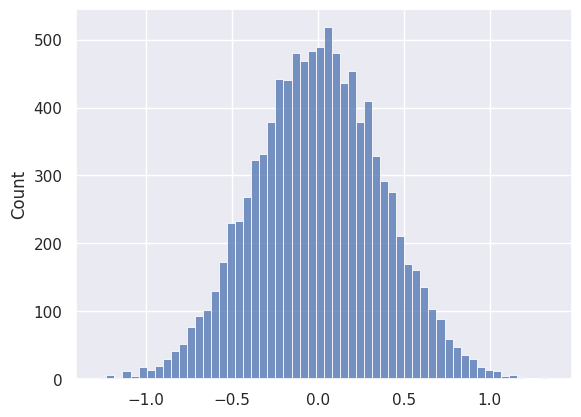

In [481]:
# @title gerando amostras
theta_true = 0.37
n_data = 10_000

original_data = torch.normal(
    mean=0.0,
    std=torch.tensor(theta_true),
    size=(n_data,)
)

sns.histplot(original_data)
plt.show()

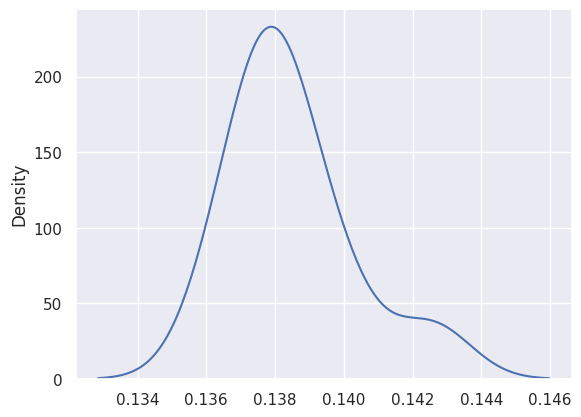

In [540]:
# @title definindo distribuições
a0 = 2
b0 = 5
# TODO: gerar Tf fake samples of theta variance
closed_form = InverseGamma(alpha = a0 + n_data / 2, beta = b0 + 0.5 * torch.sum(original_data ** 2))
# print(a0 + n_data / 2,  b0 + 0.5 * torch.sum(original_data ** 2))
theta_fake_samples = closed_form.sample(size=10)
sns.kdeplot(theta_fake_samples)
plt.show()

In [483]:
# @title Priori target (half-normal)
pi = Normal(media=0, sigma=1)

sampler_pi = Sampler(f_log_prob=pi.log)
samples_pi, burned, not_used = sampler_pi.get_samples("mh", estado_inicial=torch.as_tensor(1.0), use_log_pdf=True, n_amostras=10_000)

Amostrando:   0%|          | 0/10000 [00:00<?, ?it/s]

In [484]:
# @title Priori fake (inverse gamma)
pi_f = InverseGamma(alpha=a0, beta=b0)

sampler_pif = Sampler(f_log_prob=pi_f.log)
samples_pif, burned, not_used = sampler_pif.get_samples("mh", estado_inicial=torch.as_tensor(1.0), use_log_pdf=True, n_amostras=10_000)


Amostrando:   0%|          | 0/10000 [00:00<?, ?it/s]

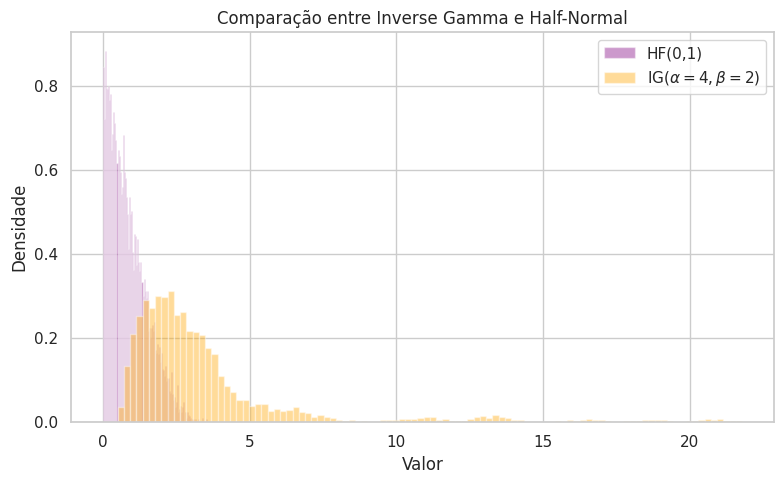

In [499]:
# @title plotando dist prioris (histplot)
plt.figure(figsize=(8, 5))

# Half-Normal
plt.hist(
    torch.abs(samples_pi).numpy(),
    bins=100,
    density=True,
    alpha=0.4,
    color="purple",
    label=r"HF(0,1)"
)

# Inverse Gamma
plt.hist(
    samples_pif.numpy(),
    bins=100,
    density=True,
    alpha=0.4,
    color="orange",
    label=r"IG($\alpha=4,\beta=2$)"
)

plt.xlabel("Valor")
plt.ylabel("Densidade")
plt.title("Comparação entre Inverse Gamma e Half-Normal")
plt.legend()
plt.tight_layout()
plt.show()

## Get Parametric

In [506]:
# TODO: encontrar alpha star
len_alpha = 1
alpha_star = fit_m2_with_adam(
    theta_samples = theta_fake_samples,
    n = n_data,
    a0=a0,
    b0=b0,
    size = len_alpha,
    steps = 1000
)
# alpha_star = estimate_alpha_vec_with_adam(
#     theta_samples = theta_fake_samples,
#     loss_function = wrapper_loss_SM_NIG(n=n_data, a=a0, b=b0),
#     k = len_alpha,
#     alpha_init_scale=1.0,
#     num_steps=1_000
# )
print(alpha_star)

Treinando m2 (Adam):   0%|          | 0/1000 [00:00<?, ?it/s]

tensor([0.1370], dtype=torch.float64)


In [507]:
print(alpha_star)

tensor([0.1370], dtype=torch.float64)


Amostrando:   0%|          | 0/1000 [00:00<?, ?it/s]

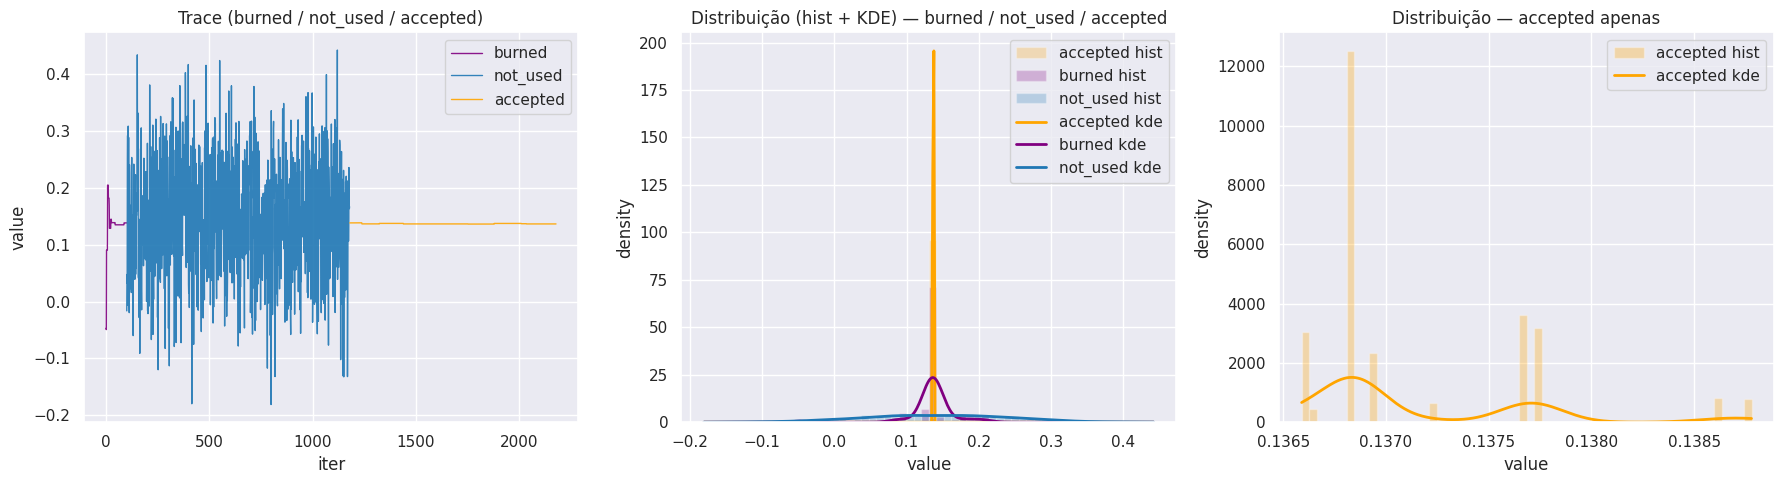

In [508]:
parametric_density = ParametricDistribution(
    target_priori=pi,
    fake_priori=pi_f,
    data_distribution=data_distribution,
    alpha_star=alpha_star,
    n = n_data,
    k = len_alpha
)

# TODO: gerar as amostras de theta usando Sampler
sampler_parametric = Sampler(f_log_prob=parametric_density.log_s)
samples_parametric, burned, not_used = sampler_parametric.get_samples(
    method="mh",
    estado_inicial=torch.as_tensor(0.000005),
    use_log_pdf=True,
    n_amostras=1000,
    burnin=0.1,
    cov_random_walk=0.01
)
sampler_parametric.plot_cadeia()

torch.Size([1000, 1])


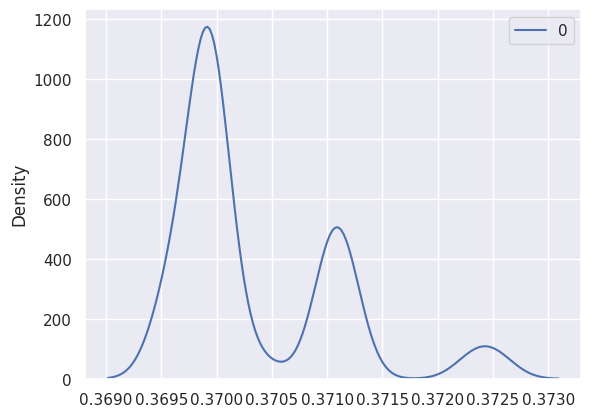

tensor(0.3703, dtype=torch.float64)


In [509]:
real_samples_final = torch.sqrt(torch.abs(samples_parametric))
sns.kdeplot(real_samples_final)
plt.show()
print(real_samples_final.mean())

## Get Semi Parametric

In [510]:
bandwidth_1 = bandwidth_scott_logtheta(thetas=theta_fake_samples)
bandwidth_2 = bandwidth_silverman_logtheta(thetas=theta_fake_samples)

print(bandwidth_1)
sm_density = SemiParametricDistribution(
    parametric_density=parametric_density,
    priori_target = pi,
    priori_fake = pi_f,
    thetas=theta_fake_samples,
    bandwidth=bandwidth_1
)

tensor(0.0077, dtype=torch.float64)


Amostrando:   0%|          | 0/100 [00:00<?, ?it/s]

Amostrando:  44%|████▍     | 28/64 [19:07<24:34, 40.97s/it]


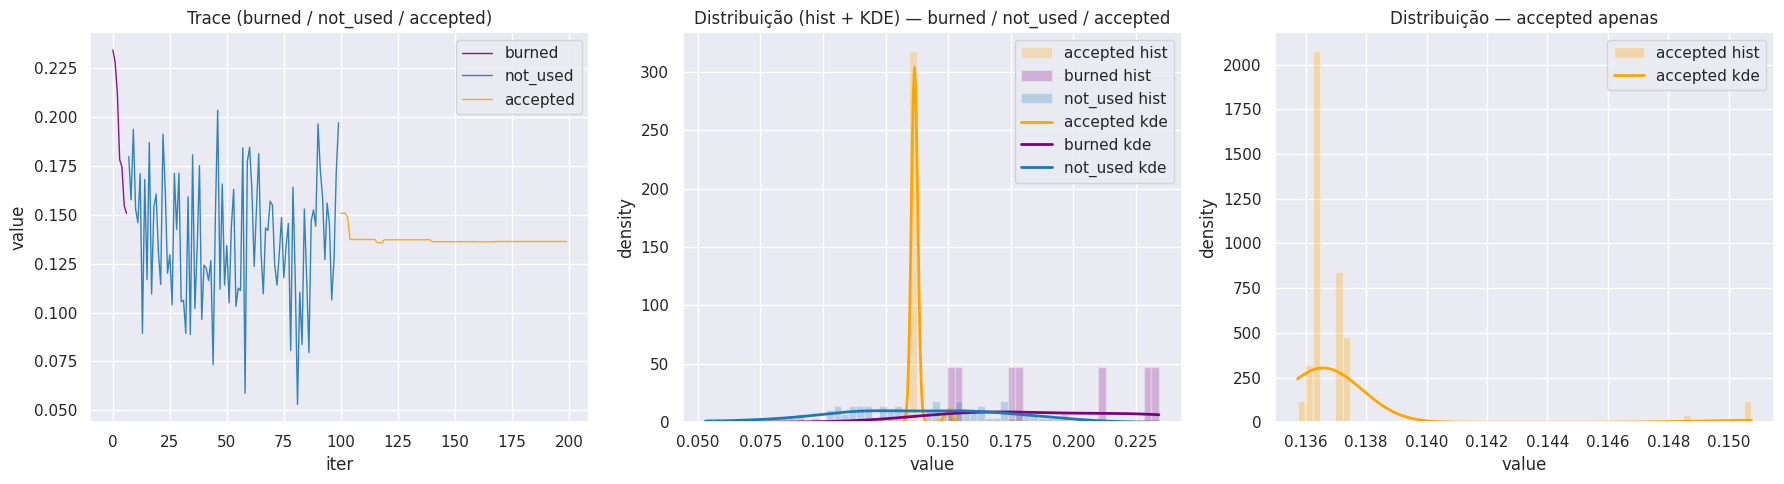

In [511]:
# TODO: gerar as amostras de theta usando Sampler
sampler_semi_parametric = Sampler(f_log_prob=sm_density.log_s)
samples_semi_parametric, burned, not_used = sampler_semi_parametric.get_samples(
    method="mh",
    estado_inicial=torch.as_tensor(0.3),
    use_log_pdf=True,
    n_amostras=100,
    burnin=0.07,
    cov_random_walk=0.001
)
sampler_semi_parametric.plot_cadeia(show_img=True, save_path="./img_2.png")

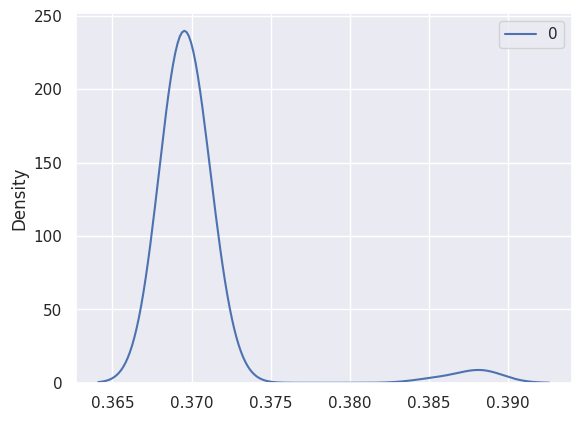

tensor(0.3703, dtype=torch.float64)


In [512]:
real_samples_final = torch.sqrt(torch.abs(samples_semi_parametric))
sns.kdeplot(real_samples_final)
plt.show()
print(real_samples_final.mean())

# Get IS/real

In [513]:
# TODO: amostrar da posteriori real!
# aqui tenho que juntar p(x|theta)pi(theta) como sendo a densidade, então vira log disso... aqui é o produtorio dos dados

def wrapper_log_likelihood(dados_originais, data_density, priori):
    def log_likelihood(theta):
        data_density_log = data_density.log(original_data, theta)
        # print(data_density_log)
        return data_density_log.sum() + priori.log(theta)

    return log_likelihood

theta = torch.as_tensor(0.7)
log_lik = wrapper_log_likelihood(original_data, data_distribution, priori=pi)

Amostrando:   0%|          | 0/10000 [00:00<?, ?it/s]

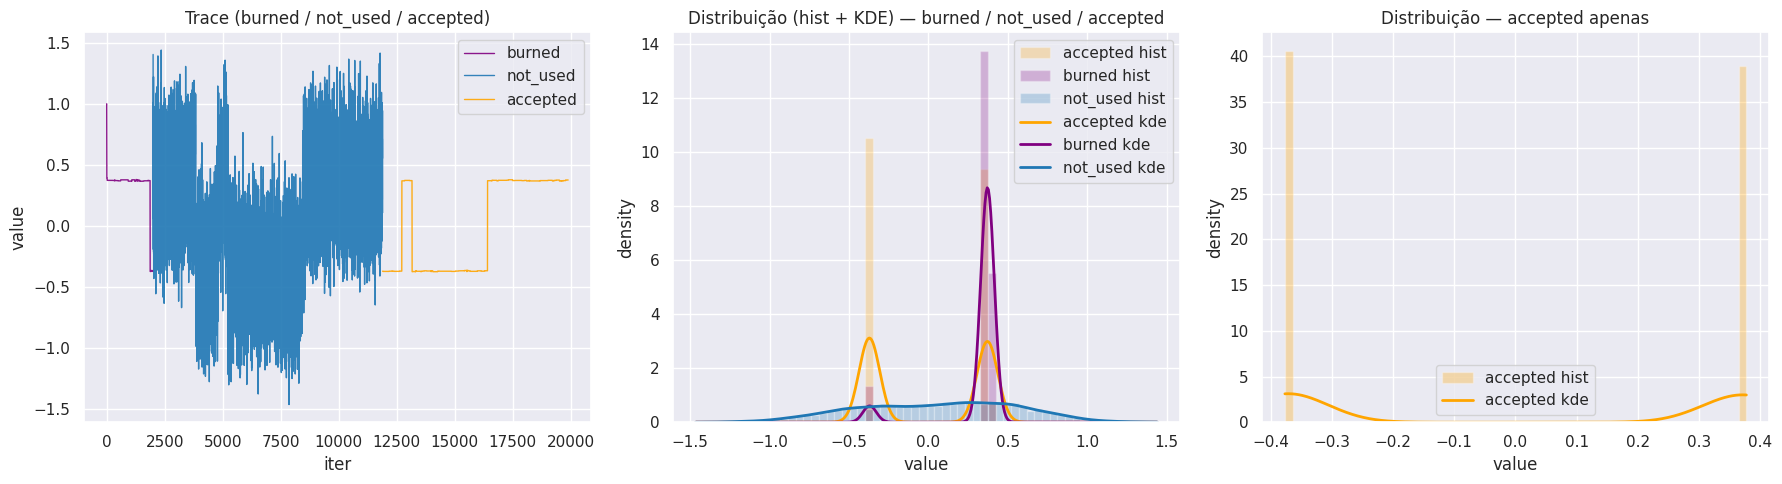

In [514]:
sampler_real_data = Sampler(f_log_prob=log_lik)
samples_real_data, burned, not_used = sampler_real_data.get_samples(
    "mh", estado_inicial=torch.as_tensor(1.0), use_log_pdf=True, n_amostras=1_000_0
)
sampler_real_data.plot_cadeia()

In [515]:
print(samples_real_data.mean())

tensor(-0.0075, dtype=torch.float64)


In [518]:
# Mostrar IS mean
denominador_pi_f = pi_f.pdf(theta_fake_samples)
numerador_pi = pi.pdf(theta_fake_samples)
weights = numerador_pi/denominador_pi_f
weights /= weights.sum()

is_thetas = weights * (torch.sqrt(theta_fake_samples))
print(torch.sqrt(theta_fake_samples).mean())
print(is_thetas.sum())

tensor(0.3714, dtype=torch.float64)
tensor(0.3706, dtype=torch.float64)


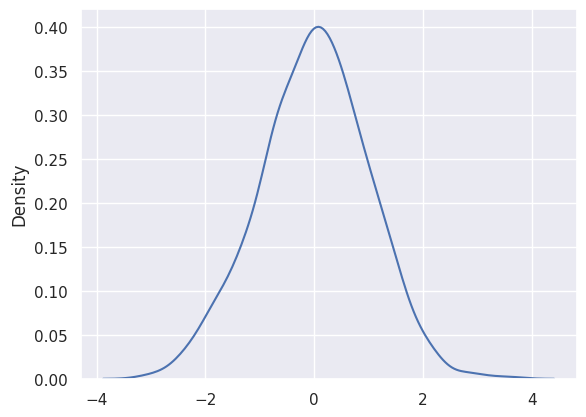

In [519]:
teste_sampler_normal = Normal(0, 1)
samples_normal_teste = teste_sampler_normal.sample(1000)
sns.kdeplot(samples_normal_teste)
plt.show()

# Comparando métodos

In [565]:
# TODO: gerar samples
# gerando dados a partir da distrbuicao
theta_true = 0.85
n_data = 10_000

original_data = torch.normal(
    mean=0.0,
    std=torch.tensor(theta_true),
    size=(n_data,)
)

# normal
pi = Normal(media=0, sigma=1)

# ig
a0 = 2
b0 = 5
pi_f = InverseGamma(alpha=a0, beta=b0)

# p(x|theta)
data_distribution = NormalVarianciaDesconhecida(0)

# amostras_theta_f
closed_form = InverseGamma(alpha = a0 + n_data / 2, beta = b0 + 0.5 * torch.sum(original_data ** 2))
samples = closed_form.sample(size=100)

# Encontrando alpjha_star
len_alpha = 1
alpha_star = fit_m2_with_adam(
    theta_samples = samples,
    n = n_data,
    a0=a0,
    b0=b0,
    size = len_alpha,
    steps = 1000,
    verbose=False
)
eixo_x, IS_, SP_, PM_, REAL_ = comparar(
    pi,
    pi_f,
    data_distribution,
    alpha_star,
    len_alpha,
    samples,
    a0,
    b0,
    10,
    10
)

Processando lotes 8:   0%|          | 0/10 [00:00<?, ?it/s]

Processando lotes 16:   0%|          | 0/10 [00:00<?, ?it/s]

Processando lotes 32:   0%|          | 0/10 [00:00<?, ?it/s]

Processando lotes 64:   0%|          | 0/10 [00:00<?, ?it/s]

Processando lotes 128:   0%|          | 0/10 [00:00<?, ?it/s]

Processando lotes 256:   0%|          | 0/10 [00:00<?, ?it/s]

Processando lotes 512:   0%|          | 0/10 [00:00<?, ?it/s]

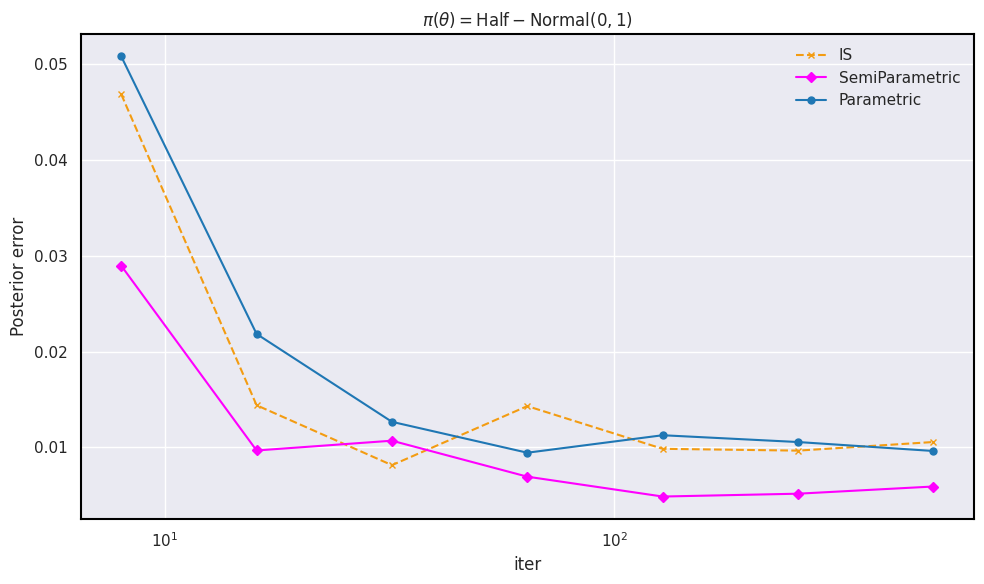

In [567]:
plt.figure(figsize=(10, 6))

real_sigma2 = torch.as_tensor(theta_true)

x = np.asarray(eixo_x)

y_is = [torch.norm(torch.as_tensor(v) - real_sigma2).item() for v in IS_]
y_sp = [torch.norm(torch.as_tensor(v) - real_sigma2).item() for v in SP_]
y_pm = [torch.norm(torch.as_tensor(v) - real_sigma2).item() for v in PM_]
y_real = [torch.norm(torch.as_tensor(v) - real_sigma2).item() for v in REAL_]


plt.plot(x, y_is, linestyle='--', marker='x', markersize=5, linewidth=1.5,
         color='#f39c12', label='IS')

plt.plot(x, y_sp, linestyle='-', marker='D', markersize=5, linewidth=1.5,
         color='#ff00ff', label='SemiParametric')

plt.plot(x, y_pm, linestyle='-', marker='o', markersize=5, linewidth=1.5,
         color='#1f77b4', label='Parametric')

# plt.plot(x, y_real, linestyle='-', marker='s', markersize=5, linewidth=1.5,
#          color='red', label='R')

plt.xscale("log")
plt.xlabel("iter")
plt.ylabel("Posterior error")
plt.title(r"$\pi(\theta)=\mathrm{Half-Normal}(0, 1)$")

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color("black")

plt.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.savefig("./comparacao_NIG_1.png")
plt.show()

Amostrando:   0%|          | 0/10000 [00:00<?, ?it/s]

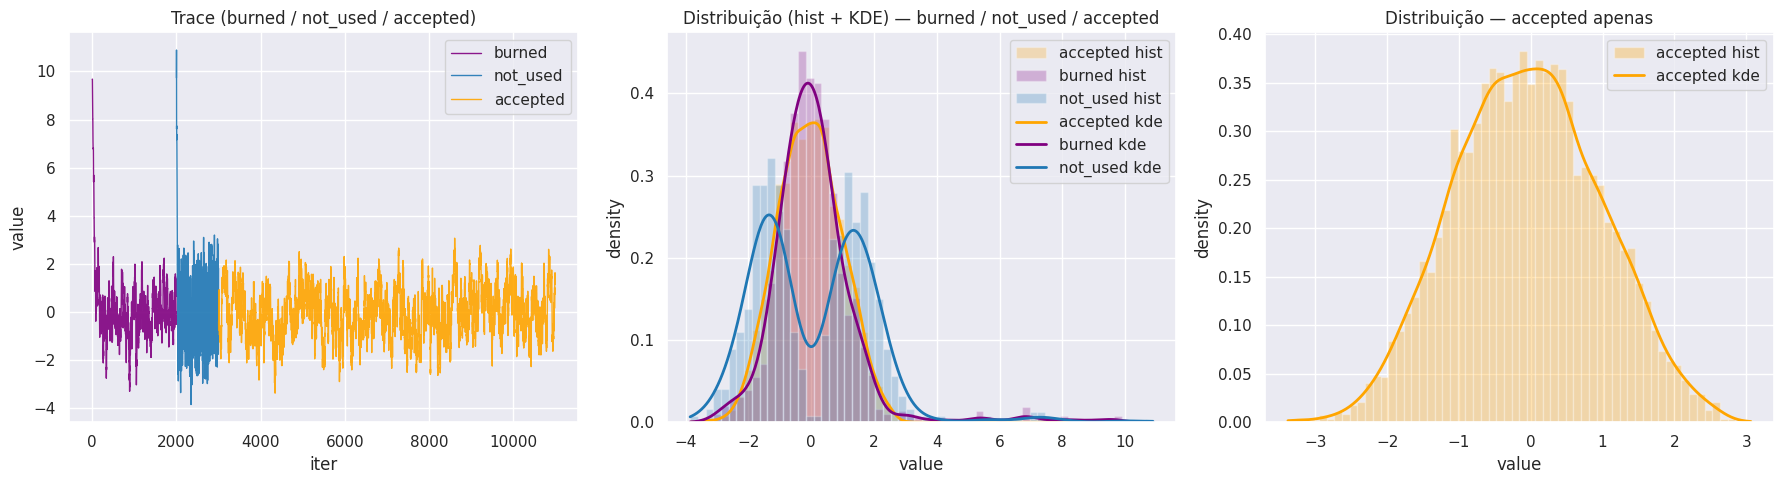

In [532]:
sampler_1_teste = Sampler(f_log_prob=teste_sampler_normal.log)
samples_normal_mc_teste = sampler_1_teste.get_samples("mh", estado_inicial=torch.as_tensor(10), use_log_pdf=True, n_amostras=10000)
sampler_1_teste.plot_cadeia()